<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning-Based Hand Gesture Recognition Using Convolutional Neural Networks**

**Dataset:** [LeapGestRecog](https://www.kaggle.com/datasets/gti-upm/leapgestrecog) 



# Setting up Kaggle API for getting the dataset



In [1]:
! pip install kaggle -q
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/          # upload kaggle.json first
! chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API configured ✓")


Kaggle API configured ✓


**Download the LeapGestRecog dataset from Kaggle and unzip it:**

In [2]:
! kaggle datasets download -d gti-upm/leapgestrecog


Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:20<00:00, 42.8MB/s]
100% 2.13G/2.13G [00:20<00:00, 110MB/s] 


In [3]:
! unzip -q leapgestrecog.zip -d leapgestrecog
! ls leapgestrecog/leapGestRecog/


00  01	02  03	04  05	06  07	08  09


# Importing Necessary Libraries
<hr>


In [4]:
import os, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, model_from_json
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPool2D, MaxPooling2D, ZeroPadding2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation, GlobalAveragePooling2D,
    DepthwiseConv2D, Add, Multiply, Reshape
)
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#

DATASET_PATH = 'leapgestrecog/leapGestRecog'
IMG_SIZE     = 64   

GESTURES = {
    '01_palm':       0,
    '02_l':          1,
    '03_fist':       2,
    '04_fist_moved': 3,
    '05_thumb':      4,
    '06_index':      5,
    '07_ok':         6,
    '08_palm_moved': 7,
    '09_c':          8,
    '10_down':       9,
}
GESTURE_NAMES = {v: k.split('_',1)[1].replace('_',' ').title() for k,v in GESTURES.items()}

records = []
for subject in sorted(os.listdir(DATASET_PATH)):
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for gesture_folder in sorted(os.listdir(subject_path)):
        label = GESTURES.get(gesture_folder)
        if label is None:
            continue
        gesture_path = os.path.join(subject_path, gesture_folder)
        for img_file in os.listdir(gesture_path):
            if img_file.lower().endswith(('.png','.jpg','.jpeg')):
                records.append({
                    'filepath': os.path.join(gesture_path, img_file),
                    'label':    label,
                    'subject':  subject,
                    'gesture':  gesture_folder
                })

df = pd.DataFrame(records)
print(f"Total images found : {len(df)}")
print(f"Gesture classes    : {df['label'].nunique()}")
df.head(5)


Total images found : 20000
Gesture classes    : 10


,filepath,label,subject,gesture
0,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
1,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
2,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
3,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
4,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm


# Exploratory Data Analysis
<hr>


In [6]:
# Basic dataframe info
print("Shape:", df.shape)
print("\nNull values:", df.isna().sum().sum())
print("\nColumn info:")
df.info()
print("\nLabel distribution:")
print(df['label'].value_counts().sort_index())


Shape: (20000, 4)

Null values: 0

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  20000 non-null  object
 1   label     20000 non-null  int64 
 2   subject   20000 non-null  object
 3   gesture   20000 non-null  object
dtypes: int64(1), object(3)
memory usage: 625.1+ KB

Label distribution:
label
0    2000
1    2000
2    2000
3    2000
4    2000
5    2000
6    2000
7    2000
8    2000
9    2000
Name: count, dtype: int64


In [7]:
# Gesture label map
print("Gesture ID → Name mapping:")
for k,v in GESTURE_NAMES.items():
    print(f"  {k:>2} → {v}")


Gesture ID → Name mapping:
   0 → Palm
   1 → L
   2 → Fist
   3 → Fist Moved
   4 → Thumb
   5 → Index
   6 → Ok
   7 → Palm Moved
   8 → C
   9 → Down


##  Images per Subject × Gesture (Grouped Bar)



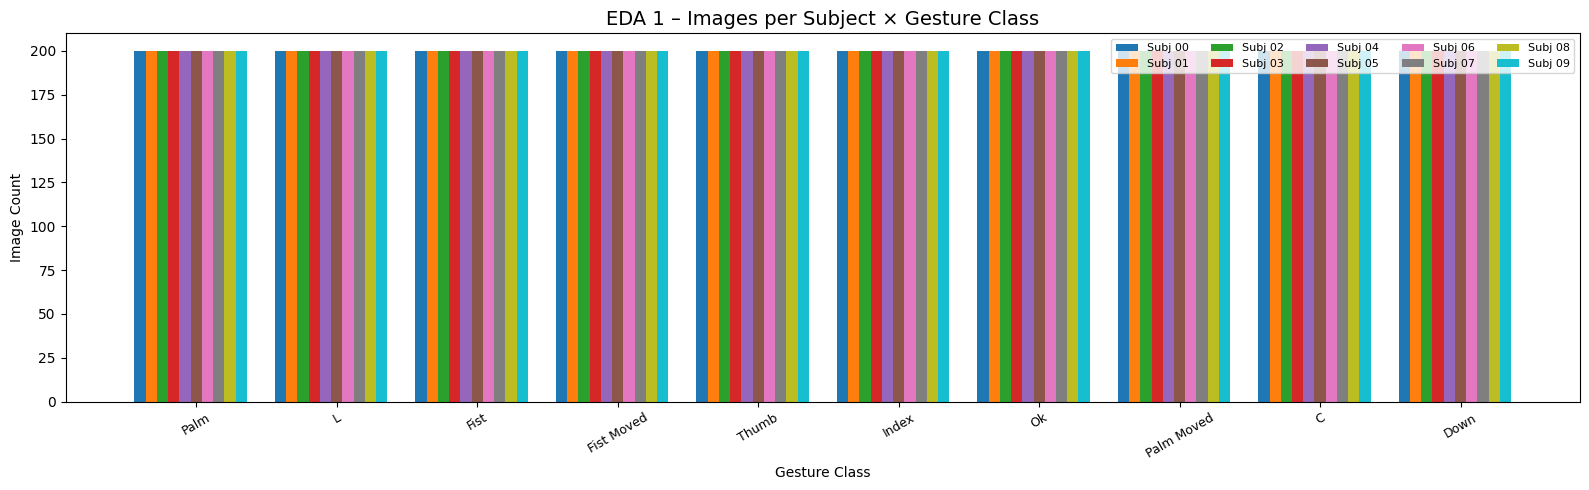


Pivot – Subject vs Gesture (image counts):
gesture  01_palm  02_l  03_fist  04_fist_moved  05_thumb  06_index  07_ok  08_palm_moved  09_c  10_down
subject                                                                                                
00           200   200      200            200       200       200    200            200   200      200
01           200   200      200            200       200       200    200            200   200      200
02           200   200      200            200       200       200    200            200   200      200
03           200   200      200            200       200       200    200            200   200      200
04           200   200      200            200       200       200    200            200   200      200
05           200   200      200            200       200       200    200            200   200      200
06           200   200      200            200       200       200    200            200   200      200
07           200   2

In [ ]:

subjects  = sorted(df['subject'].unique())
n_subj    = len(subjects)
x         = np.arange(10)
width     = 0.08
cmap      = plt.cm.tab10(np.linspace(0, 1, n_subj))

fig, ax = plt.subplots(figsize=(16, 5))
for idx, subj in enumerate(subjects):
    counts = [df[(df['subject']==subj) & (df['label']==g)].shape[0] for g in range(10)]
    ax.bar(x + idx*width, counts, width, label=f'Subj {subj}', color=cmap[idx])

ax.set_xticks(x + width*n_subj/2)
ax.set_xticklabels([GESTURE_NAMES[i] for i in range(10)], rotation=30, fontsize=9)
ax.set_title('EDA 1 – Images per Subject × Gesture Class', fontsize=14)
ax.set_xlabel('Gesture Class'); ax.set_ylabel('Image Count')
ax.legend(ncol=5, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

# Also print the pivot table
pivot = pd.crosstab(df['subject'], df['gesture'])
print("\nPivot – Subject vs Gesture (image counts):")
print(pivot.to_string())


##  Gesture Pair Confusion Potential (Similarity Score)



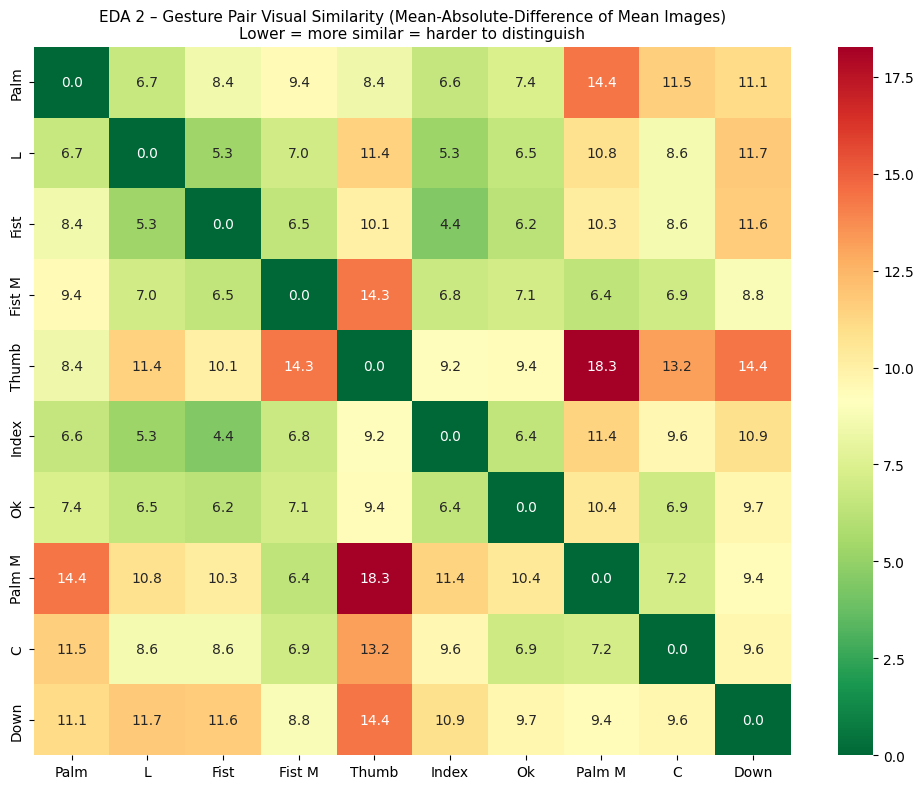

Most visually similar gesture pairs (MAD < 30):
  Palm ↔ L: MAD=6.7
  Palm ↔ Fist: MAD=8.4
  Palm ↔ Fist Moved: MAD=9.4
  Palm ↔ Thumb: MAD=8.4
  Palm ↔ Index: MAD=6.6
  Palm ↔ Ok: MAD=7.4
  Palm ↔ Palm Moved: MAD=14.4
  Palm ↔ C: MAD=11.5
  Palm ↔ Down: MAD=11.1
  L ↔ Fist: MAD=5.3
  L ↔ Fist Moved: MAD=7.0
  L ↔ Thumb: MAD=11.4
  L ↔ Index: MAD=5.3
  L ↔ Ok: MAD=6.5
  L ↔ Palm Moved: MAD=10.8
  L ↔ C: MAD=8.6
  L ↔ Down: MAD=11.7
  Fist ↔ Fist Moved: MAD=6.5
  Fist ↔ Thumb: MAD=10.1
  Fist ↔ Index: MAD=4.4
  Fist ↔ Ok: MAD=6.2
  Fist ↔ Palm Moved: MAD=10.3
  Fist ↔ C: MAD=8.6
  Fist ↔ Down: MAD=11.6
  Fist Moved ↔ Thumb: MAD=14.3
  Fist Moved ↔ Index: MAD=6.8
  Fist Moved ↔ Ok: MAD=7.1
  Fist Moved ↔ Palm Moved: MAD=6.4
  Fist Moved ↔ C: MAD=6.9
  Fist Moved ↔ Down: MAD=8.8
  Thumb ↔ Index: MAD=9.2
  Thumb ↔ Ok: MAD=9.4
  Thumb ↔ Palm Moved: MAD=18.3
  Thumb ↔ C: MAD=13.2
  Thumb ↔ Down: MAD=14.4
  Index ↔ Ok: MAD=6.4
  Index ↔ Palm Moved: MAD=11.4
  Index ↔ C: MAD=9.6
  Index ↔ Down

In [ ]:

N = 50
mean_imgs = {}
for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(N, random_state=0).tolist()
    imgs  = [cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE),
                        (IMG_SIZE, IMG_SIZE)).astype(np.float32) for p in paths if cv2.imread(p) is not None]
    mean_imgs[gid] = np.stack(imgs).mean(axis=0)

# Pairwise mean-absolute-difference
sim_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        sim_matrix[i, j] = np.abs(mean_imgs[i] - mean_imgs[j]).mean()

labels_short = [GESTURE_NAMES[i][:6] for i in range(10)]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=labels_short, yticklabels=labels_short, ax=ax)
ax.set_title('EDA 2 – Gesture Pair Visual Similarity (Mean-Absolute-Difference of Mean Images)\n'
             'Lower = more similar = harder to distinguish', fontsize=11)
plt.tight_layout(); plt.show()
print("Most visually similar gesture pairs (MAD < 30):")
for i in range(10):
    for j in range(i+1, 10):
        if sim_matrix[i,j] < 30:
            print(f"  {GESTURE_NAMES[i]} ↔ {GESTURE_NAMES[j]}: MAD={sim_matrix[i,j]:.1f}")


##  Foreground Coverage Ratio per Gesture Class



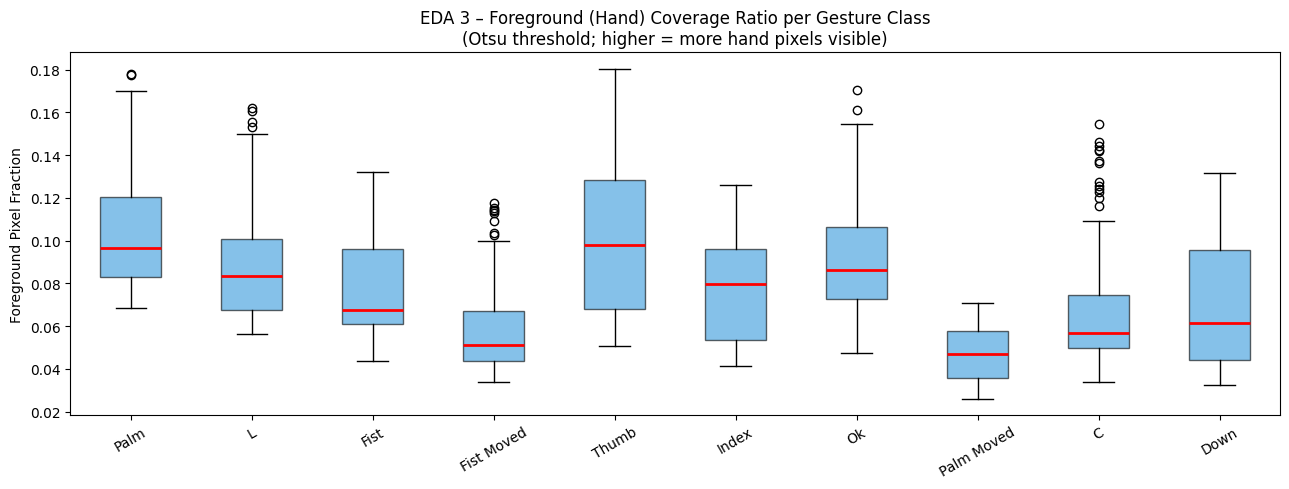

Palm          : mean=0.106  std=0.028
L             : mean=0.090  std=0.028
Fist          : mean=0.075  std=0.024
Fist Moved    : mean=0.059  std=0.022
Thumb         : mean=0.103  std=0.037
Index         : mean=0.077  std=0.022
Ok            : mean=0.090  std=0.025
Palm Moved    : mean=0.047  std=0.011
C             : mean=0.068  std=0.031
Down          : mean=0.072  std=0.030


In [ ]:

fg_ratios = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=100, random_state=3).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        fg_ratios[gid].append((thresh > 0).mean())

# Box-plot
fig, ax = plt.subplots(figsize=(13, 5))
data   = [fg_ratios[g] for g in range(10)]
labels = [GESTURE_NAMES[g] for g in range(10)]
bp = ax.boxplot(data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('EDA 3 – Foreground (Hand) Coverage Ratio per Gesture Class\n'
             '(Otsu threshold; higher = more hand pixels visible)', fontsize=12)
ax.set_ylabel('Foreground Pixel Fraction'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

for gid in range(10):
    vals = fg_ratios[gid]
    print(f"{GESTURE_NAMES[gid]:<14}: mean={np.mean(vals):.3f}  std={np.std(vals):.3f}")


##  Image Sharpness Distribution per Gesture Class



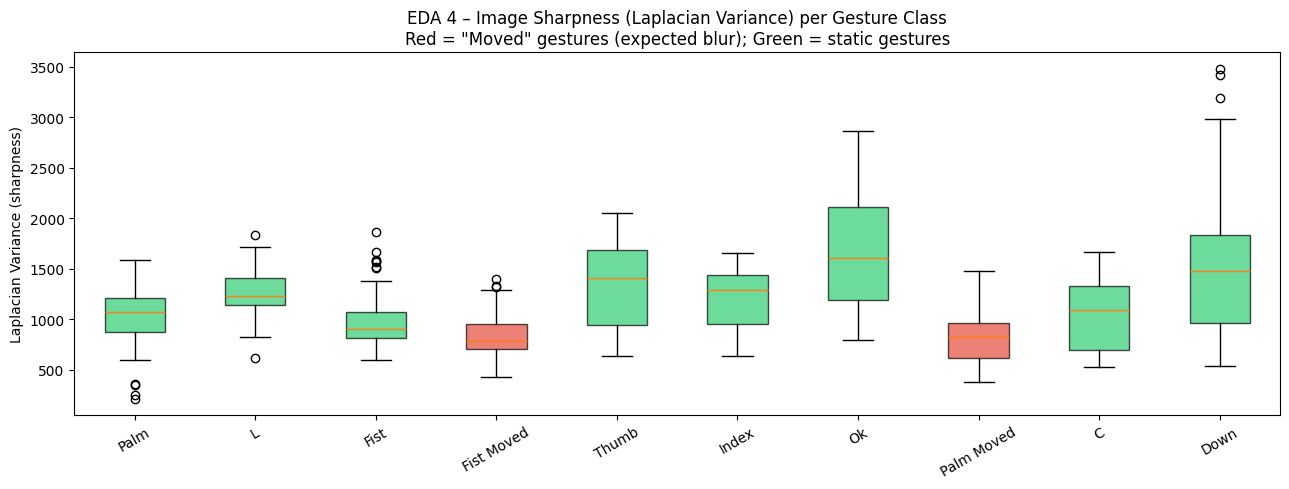

In [ ]:

sharpness = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=100, random_state=5).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        lap  = cv2.Laplacian(img.astype(np.float64), cv2.CV_64F)
        sharpness[gid].append(lap.var())

fig, ax = plt.subplots(figsize=(13, 5))
data   = [sharpness[g] for g in range(10)]
colors = ['#e74c3c' if 'moved' in GESTURE_NAMES[g].lower() else '#2ecc71' for g in range(10)]
bp = ax.boxplot(data, labels=[GESTURE_NAMES[g] for g in range(10)],
                patch_artist=True,
                boxprops=dict(alpha=0.7))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('EDA 4 – Image Sharpness (Laplacian Variance) per Gesture Class\n'
             'Red = "Moved" gestures (expected blur); Green = static gestures', fontsize=12)
ax.set_ylabel('Laplacian Variance (sharpness)'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


##  Gesture Aspect-Ratio & Bounding-Box Width-to-Height Distribution


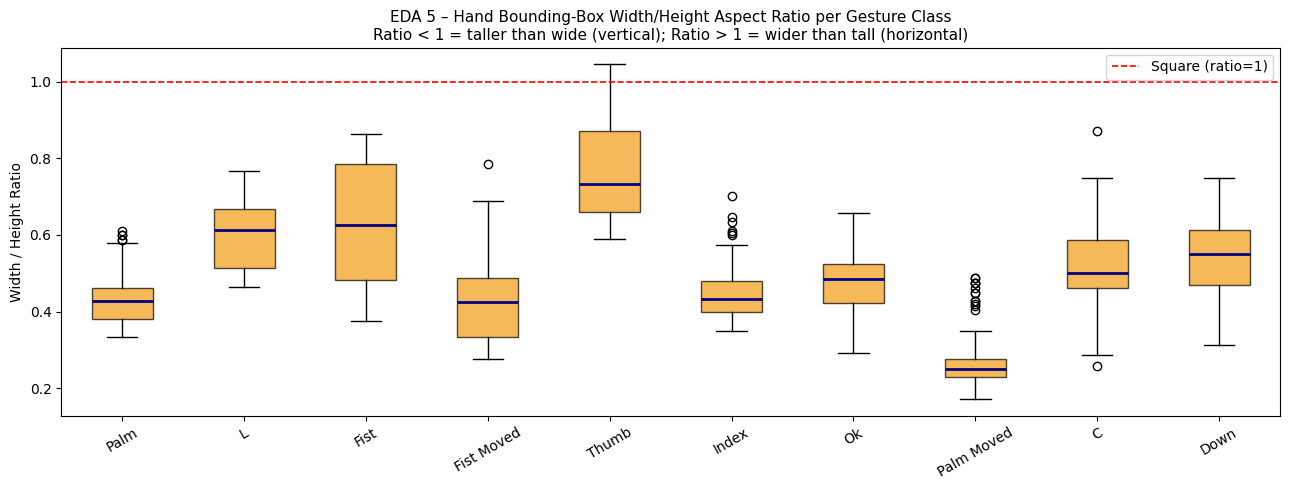

Palm          : median=0.429  orientation=vertical
L             : median=0.613  orientation=vertical
Fist          : median=0.625  orientation=vertical
Fist Moved    : median=0.426  orientation=vertical
Thumb         : median=0.733  orientation=vertical
Index         : median=0.433  orientation=vertical
Ok            : median=0.485  orientation=vertical
Palm Moved    : median=0.250  orientation=vertical
C             : median=0.500  orientation=vertical
Down          : median=0.550  orientation=vertical


In [ ]:

aspect_ratios = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=80, random_state=9).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        coords = cv2.findNonZero(thresh)
        if coords is None: continue
        x, y, w, h = cv2.boundingRect(coords)
        if h > 0:
            aspect_ratios[gid].append(w / h)

fig, ax = plt.subplots(figsize=(13, 5))
data   = [aspect_ratios[g] for g in range(10)]
bp = ax.boxplot(data, labels=[GESTURE_NAMES[g] for g in range(10)],
                patch_artist=True, boxprops=dict(facecolor='#f39c12', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2))
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Square (ratio=1)')
ax.set_title('EDA 5 – Hand Bounding-Box Width/Height Aspect Ratio per Gesture Class\n'
             'Ratio < 1 = taller than wide (vertical); Ratio > 1 = wider than tall (horizontal)', fontsize=11)
ax.set_ylabel('Width / Height Ratio'); ax.tick_params(axis='x', rotation=30); ax.legend()
plt.tight_layout(); plt.show()

for gid in range(10):
    vals = aspect_ratios[gid]
    print(f"{GESTURE_NAMES[gid]:<14}: median={np.median(vals):.3f}  "
          f"orientation={'horizontal' if np.median(vals)>=1 else 'vertical'}")


## Visualising Sample Images from the Dataset

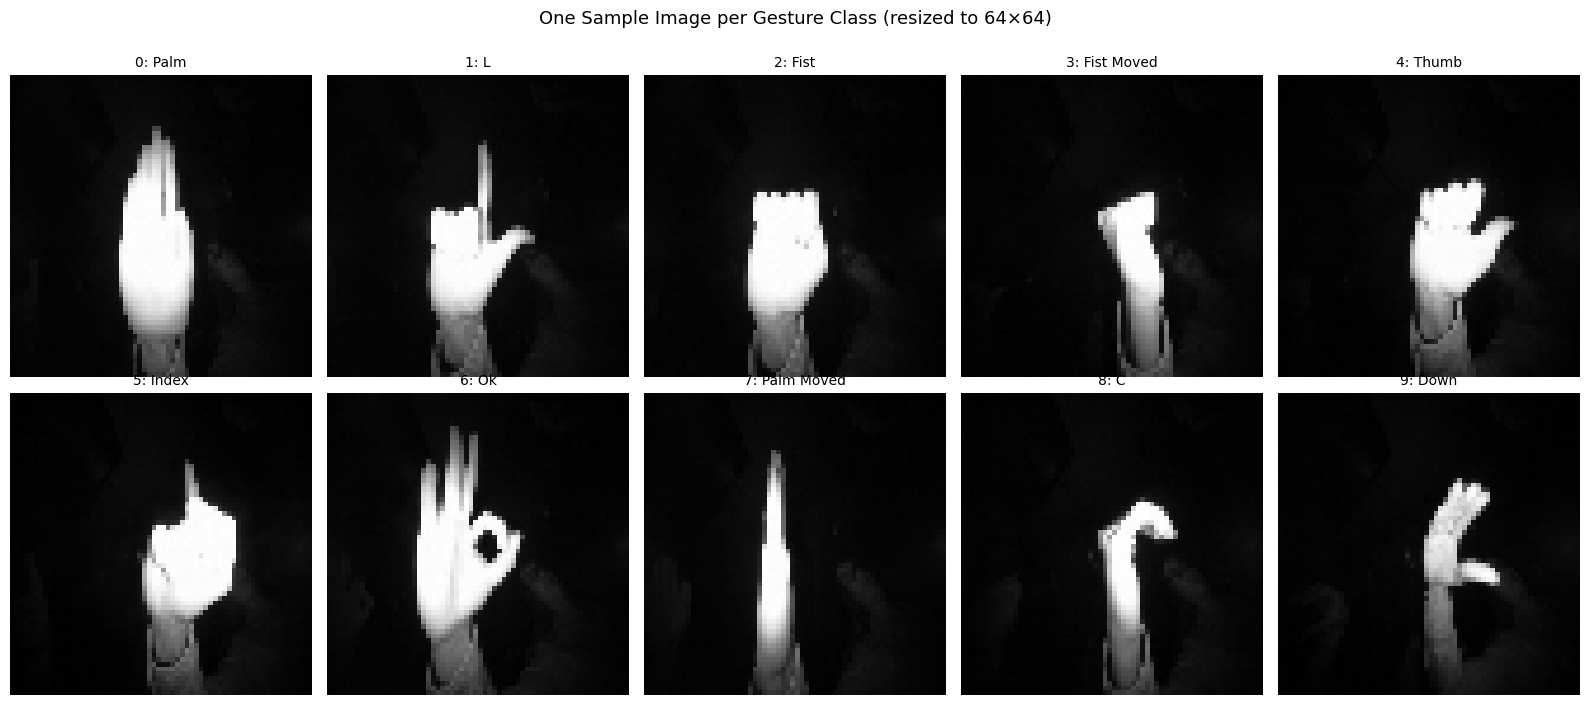

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    sample_path = df[df['label']==gid]['filepath'].iloc[0]
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{gid}: {GESTURE_NAMES[gid]}', fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample Image per Gesture Class (resized to 64×64)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# Image Processing



## Otsu Binary Thresholding (Hand Segmentation)



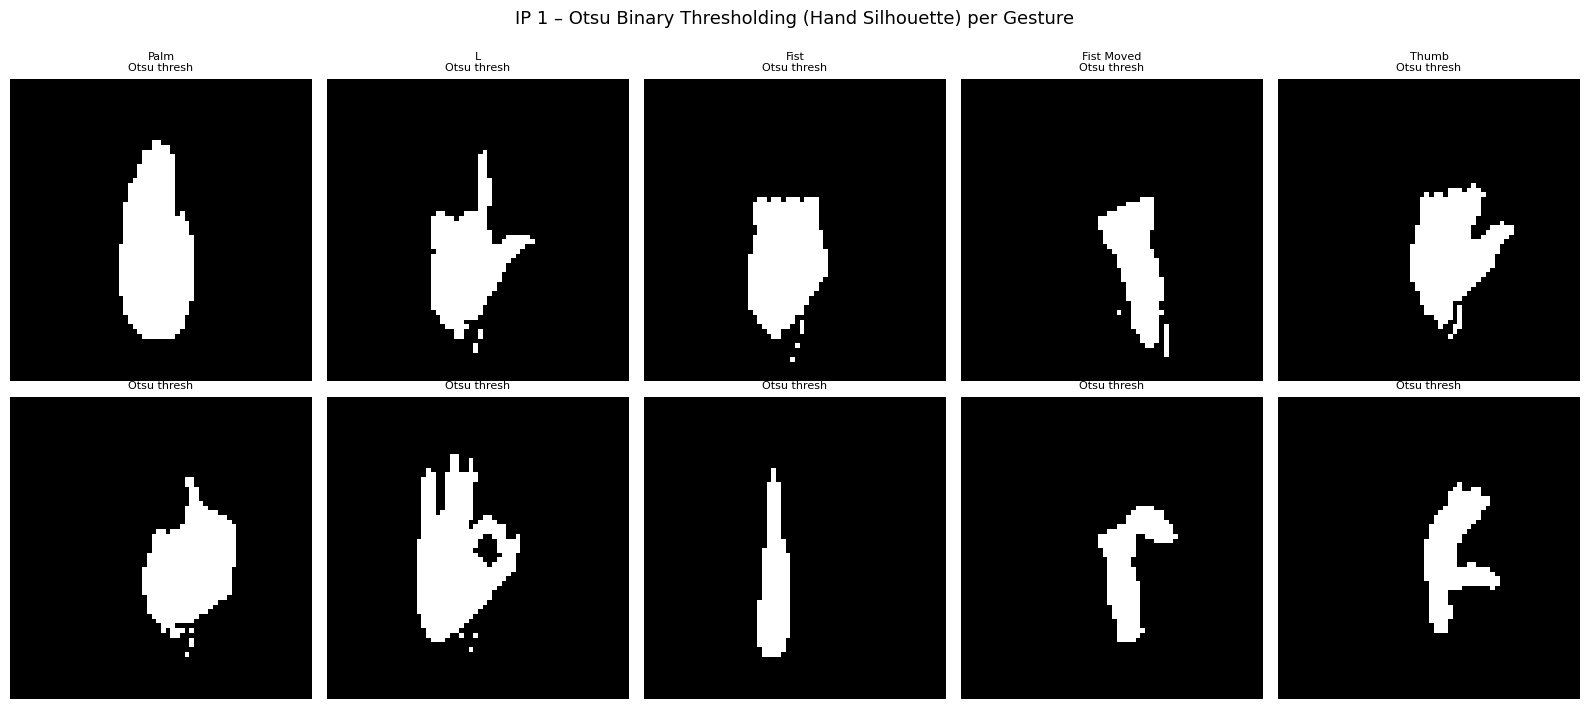

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nOtsu thresh', fontsize=8)
    ax.axis('off')
plt.suptitle('IP 1 – Otsu Binary Thresholding (Hand Silhouette) per Gesture', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Contour Extraction & Convex Hull



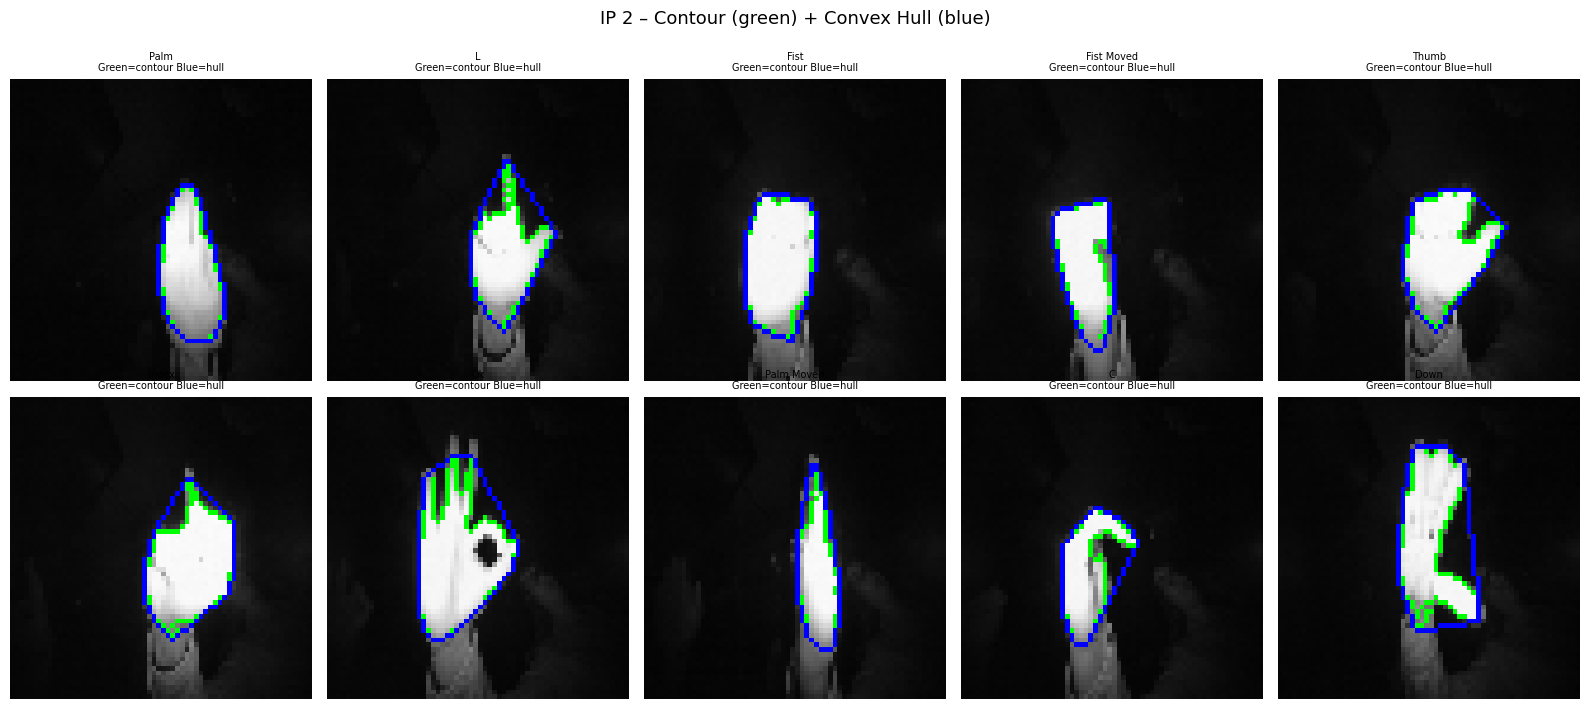

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[2]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if contours:
        cnt  = max(contours, key=cv2.contourArea)
        hull = cv2.convexHull(cnt)
        cv2.drawContours(canvas, [cnt],  -1, (0, 255, 0), 1)
        cv2.drawContours(canvas, [hull], -1, (255, 0, 0), 1)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{GESTURE_NAMES[gid]}\nGreen=contour Blue=hull', fontsize=7)
    ax.axis('off')
plt.suptitle('IP 2 – Contour (green) + Convex Hull (blue)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Distance Transform (Finger Skeleton Proxy)



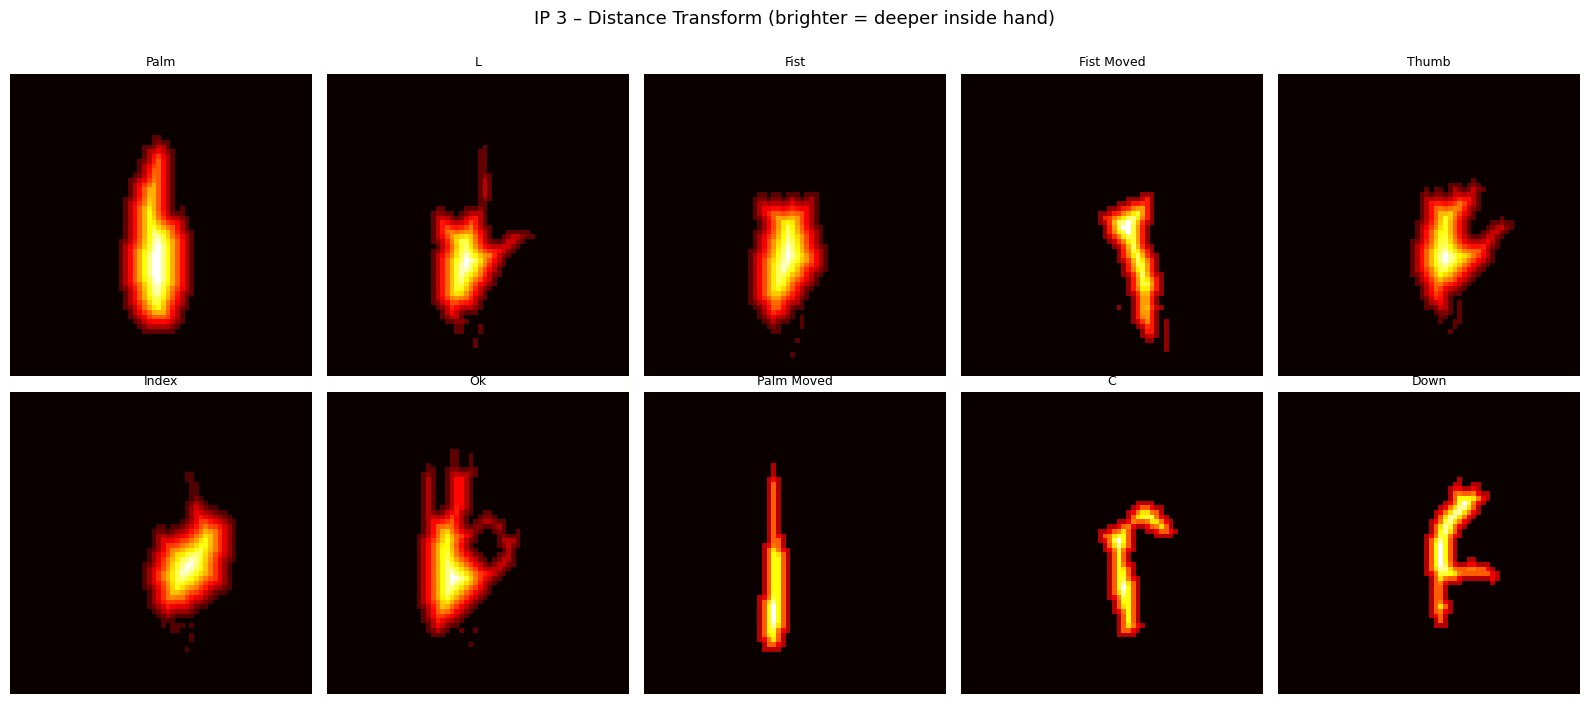

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
    im = ax.imshow(dist_norm, cmap='hot')
    ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 3 – Distance Transform (brighter = deeper inside hand)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Laplacian of Gaussian (LoG) Blob Detection



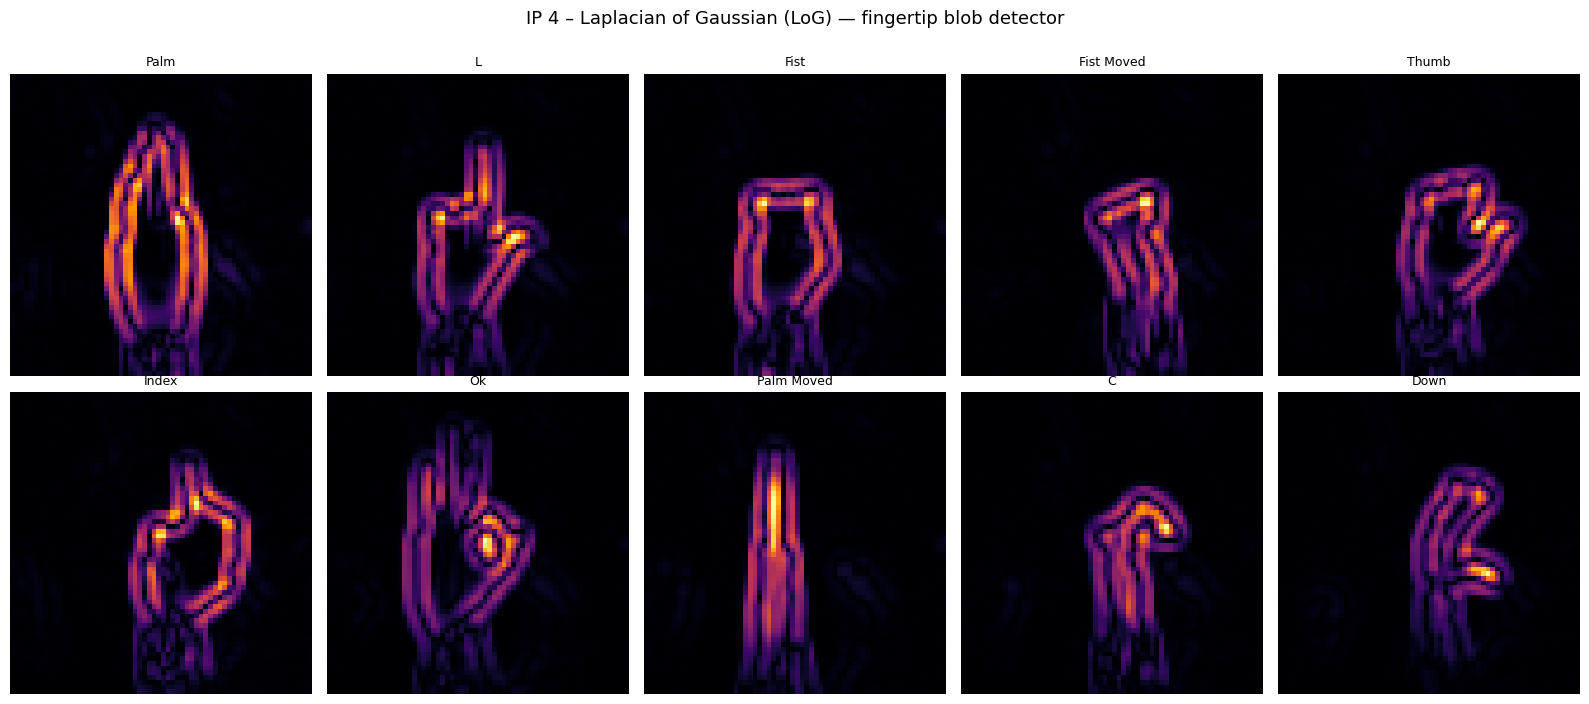

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    blurred = cv2.GaussianBlur(img, (5, 5), 1.5)
    # Convert blurred image to float64 to match the ddepth of cv2.CV_64F
    log     = cv2.Laplacian(blurred.astype(np.float64), cv2.CV_64F)
    log_abs = np.abs(log)
    log_norm = (log_abs / log_abs.max() * 255).astype(np.uint8)
    ax.imshow(log_norm, cmap='inferno'); ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 4 – Laplacian of Gaussian (LoG) — fingertip blob detector', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Gabor Filter Bank (Texture / Orientation Analysis)
A bank of **Gabor filters** at 4 orientations (0°, 45°, 90°, 135°) captures
finger-edge orientations. Each filter responds to edges at its specific angle —
together they form an orientation-sensitive texture descriptor for the hand shape.


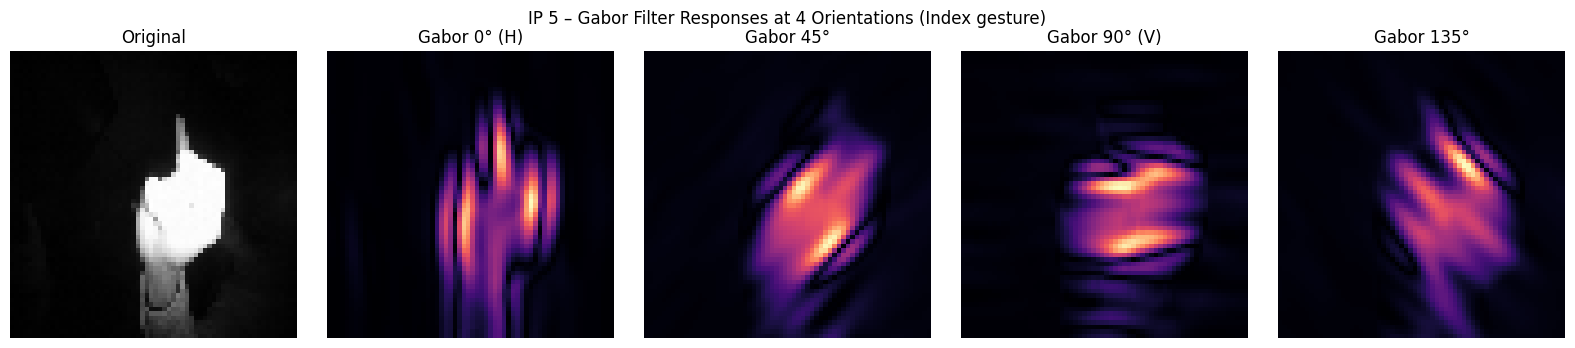

In [ ]:

def gabor_filter(img, theta):
    kern = cv2.getGaborKernel((15, 15), sigma=3.0, theta=theta,
                               lambd=8.0, gamma=0.5, psi=0)
    return cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kern)

path     = df[df['label']==5]['filepath'].iloc[0]   # Index finger
img_orig = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
thetas   = [0, np.pi/4, np.pi/2, 3*np.pi/4]
theta_labels = ['0° (H)', '45°', '90° (V)', '135°']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(img_orig, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for ax, theta, lbl in zip(axes[1:], thetas, theta_labels):
    resp = gabor_filter(img_orig, theta)
    ax.imshow(np.abs(resp), cmap='magma'); ax.set_title(f'Gabor {lbl}'); ax.axis('off')
plt.suptitle('IP 5 – Gabor Filter Responses at 4 Orientations (Index gesture)', fontsize=12)
plt.tight_layout(); plt.show()


##  HOG (Histogram of Oriented Gradients) Visualisation



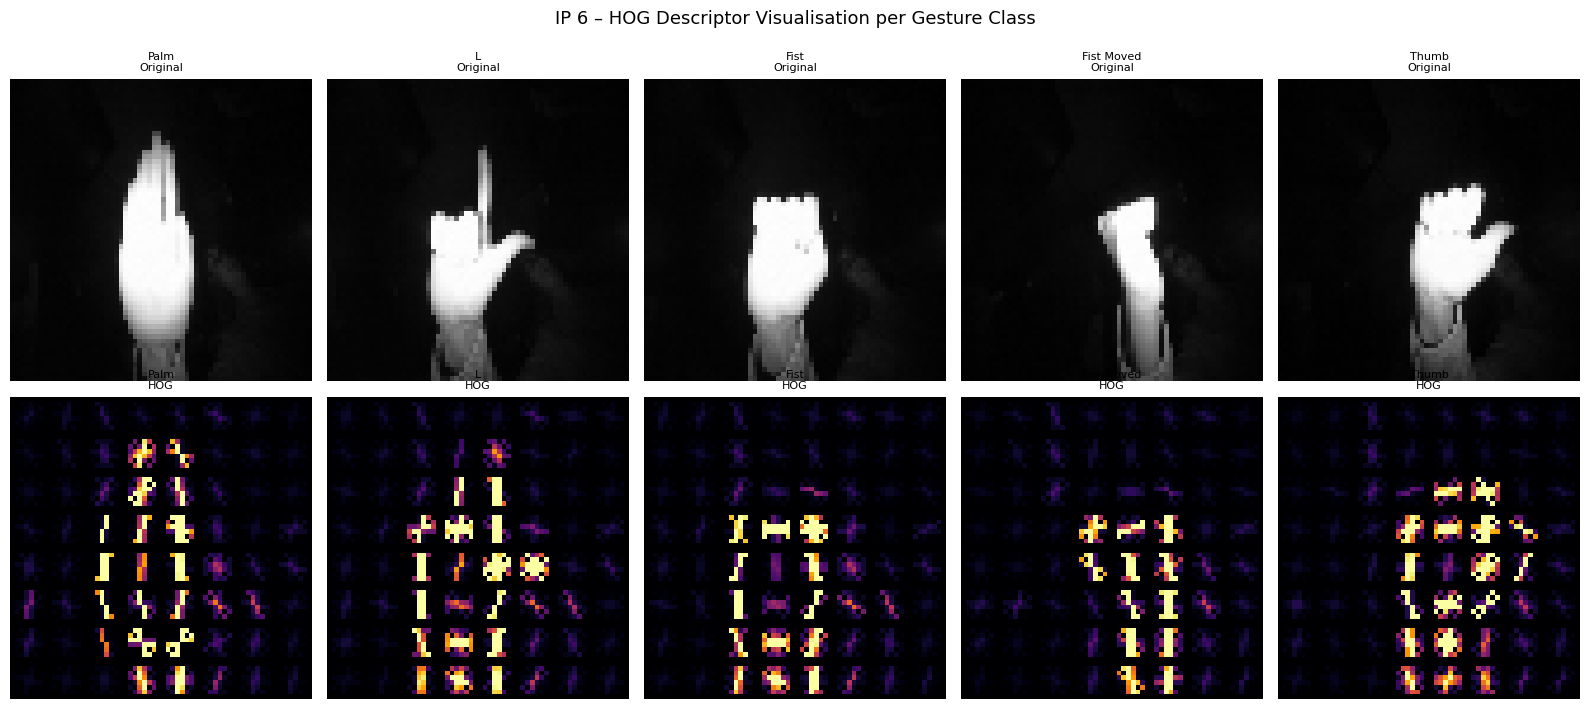

In [ ]:

from skimage.feature import hog
from skimage import exposure

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, (ax_orig, ax_hog) in enumerate(zip(axes[0], axes[1])):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    fd, hog_img = hog(img, orientations=8, pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2), visualize=True)
    hog_img_rs = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    ax_orig.imshow(img,       cmap='gray');   ax_orig.set_title(f'{GESTURE_NAMES[gid]}\nOriginal',  fontsize=8); ax_orig.axis('off')
    ax_hog.imshow(hog_img_rs, cmap='inferno'); ax_hog.set_title(f'{GESTURE_NAMES[gid]}\nHOG',       fontsize=8); ax_hog.axis('off')
plt.suptitle('IP 6 – HOG Descriptor Visualisation per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Skeleton / Thinning (Medial Axis)



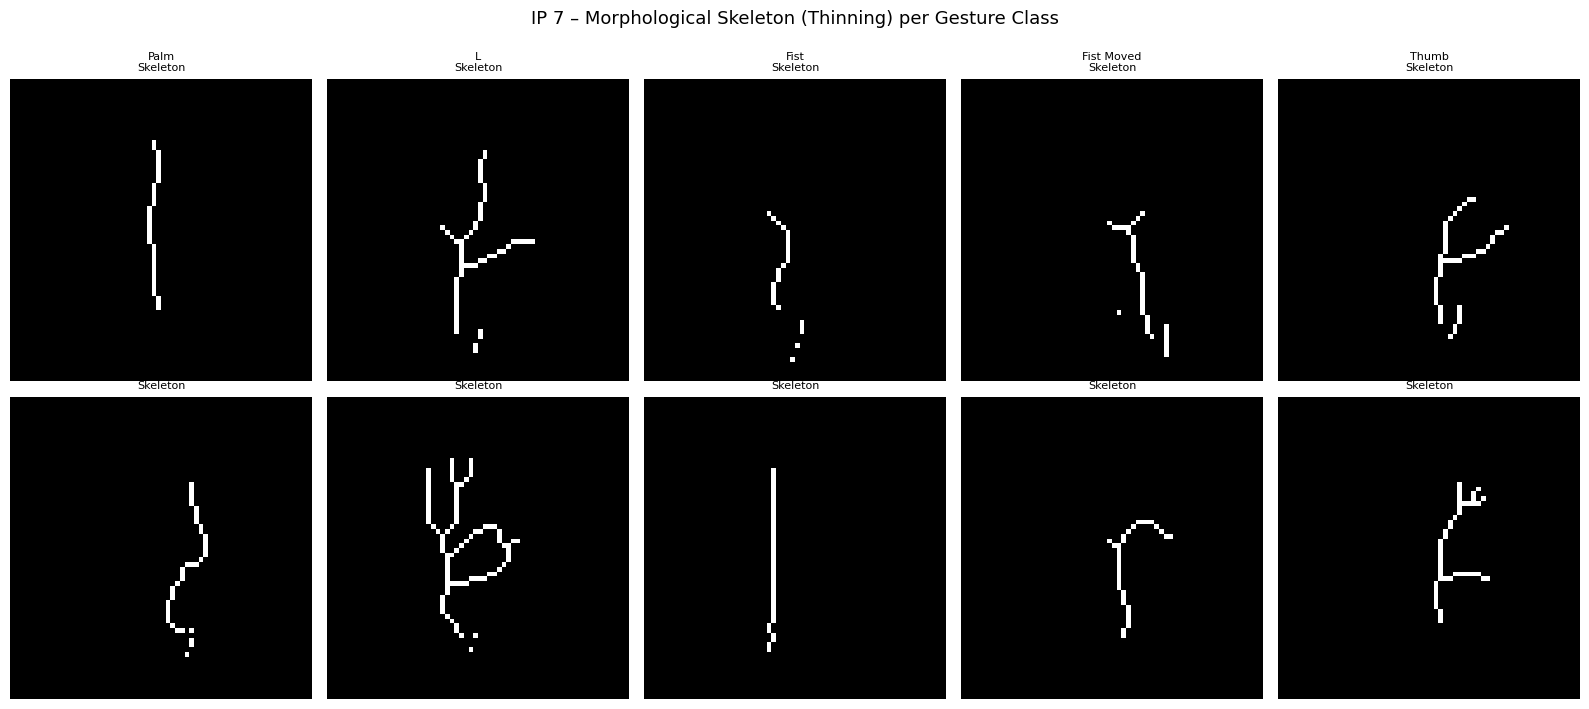

In [ ]:

from skimage.morphology import skeletonize

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path  = df[df['label']==gid]['filepath'].iloc[0]
    img   = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    skel  = skeletonize(thresh > 0).astype(np.uint8) * 255
    ax.imshow(skel, cmap='gray')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nSkeleton', fontsize=8); ax.axis('off')
plt.suptitle('IP 7 – Morphological Skeleton (Thinning) per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## LBP (Local Binary Pattern) Texture Map



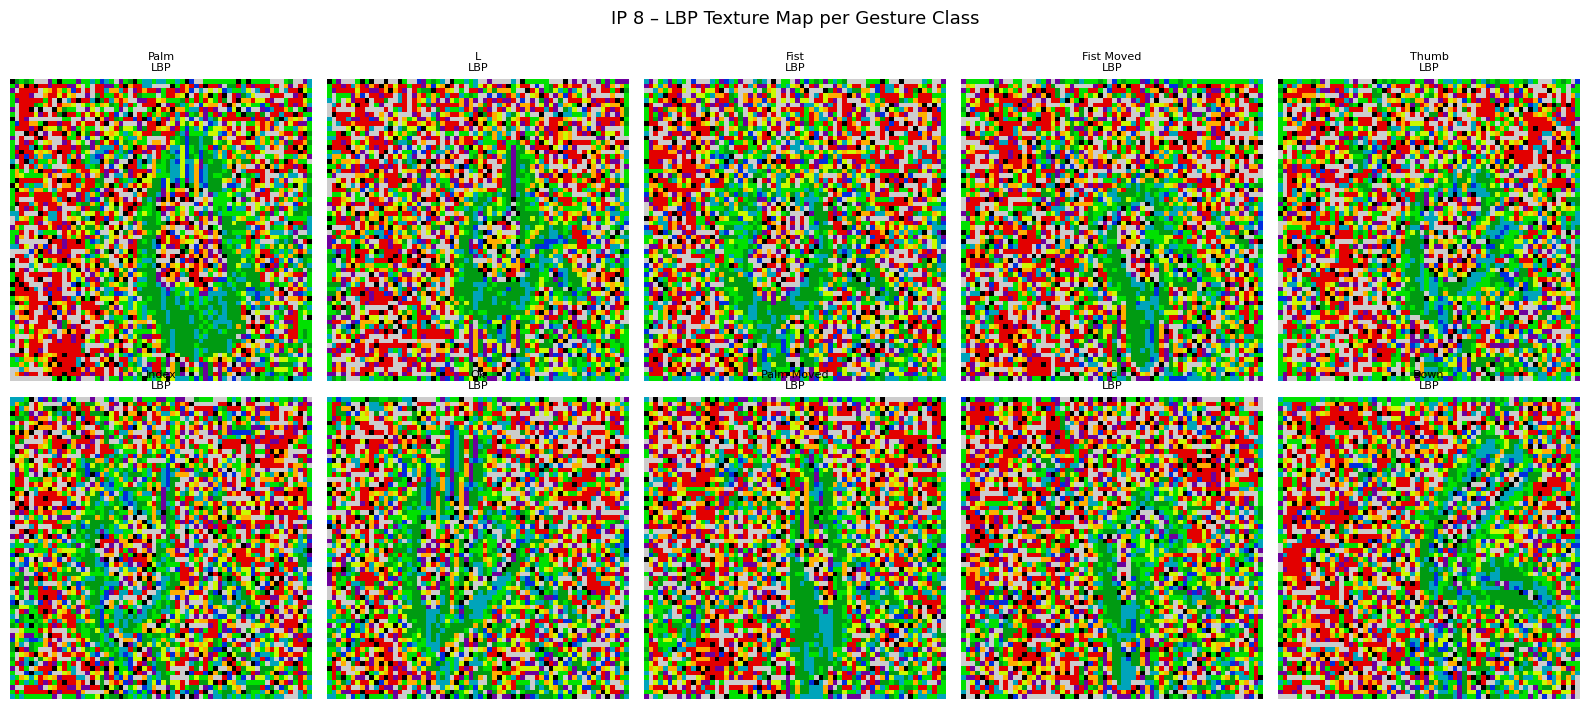

In [ ]:

from skimage.feature import local_binary_pattern

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[1]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    lbp  = local_binary_pattern(img, P=8, R=1, method='uniform')
    ax.imshow(lbp, cmap='nipy_spectral')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nLBP', fontsize=8); ax.axis('off')
plt.suptitle('IP 8 – LBP Texture Map per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Finger Count Estimation via Convexity Defects


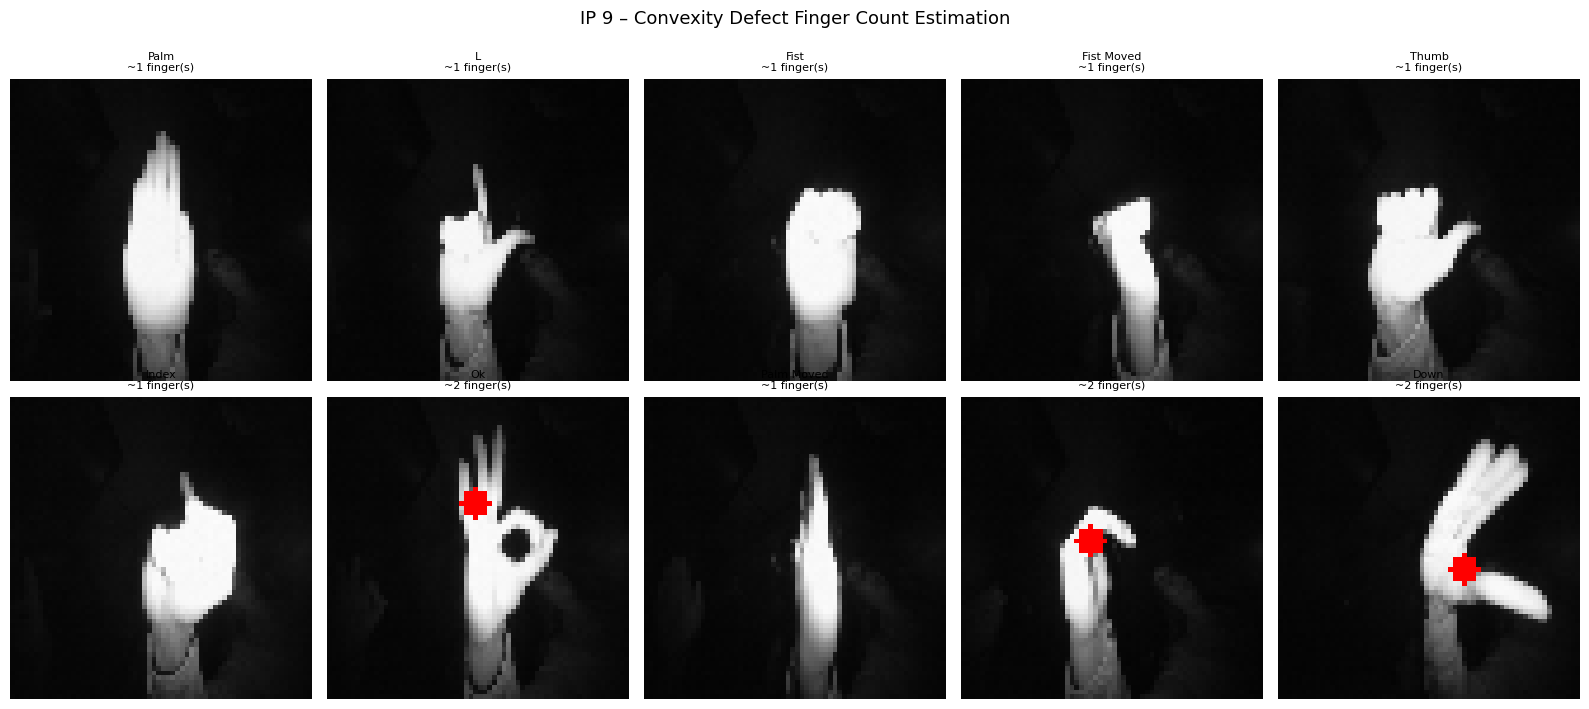

In [ ]:

def estimate_fingers(img_gray):
    _, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0, img_gray
    cnt   = max(contours, key=cv2.contourArea)
    hull  = cv2.convexHull(cnt, returnPoints=False)
    if len(hull) < 4: return 0, img_gray
    defects = cv2.convexityDefects(cnt, hull)
    if defects is None: return 0, img_gray
    count   = 0
    canvas  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(cnt[s][0]); end = tuple(cnt[e][0]); far = tuple(cnt[f][0])
        a = np.linalg.norm(np.array(end) - np.array(start))
        b = np.linalg.norm(np.array(far) - np.array(start))
        c = np.linalg.norm(np.array(end) - np.array(far))
        angle = np.arccos(max(-1, min(1, (b**2 + c**2 - a**2) / (2*b*c + 1e-6))))
        if angle < np.pi/2 and d > 2000:
            count += 1
            cv2.circle(canvas, far, 3, (0, 0, 255), -1)
    return count + 1, canvas

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[3]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    n_fingers, canvas = estimate_fingers(img)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{GESTURE_NAMES[gid]}\n~{n_fingers} finger(s)', fontsize=8); ax.axis('off')
plt.suptitle('IP 9 – Convexity Defect Finger Count Estimation', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Frequency Domain Analysis (2D FFT Magnitude Spectrum)



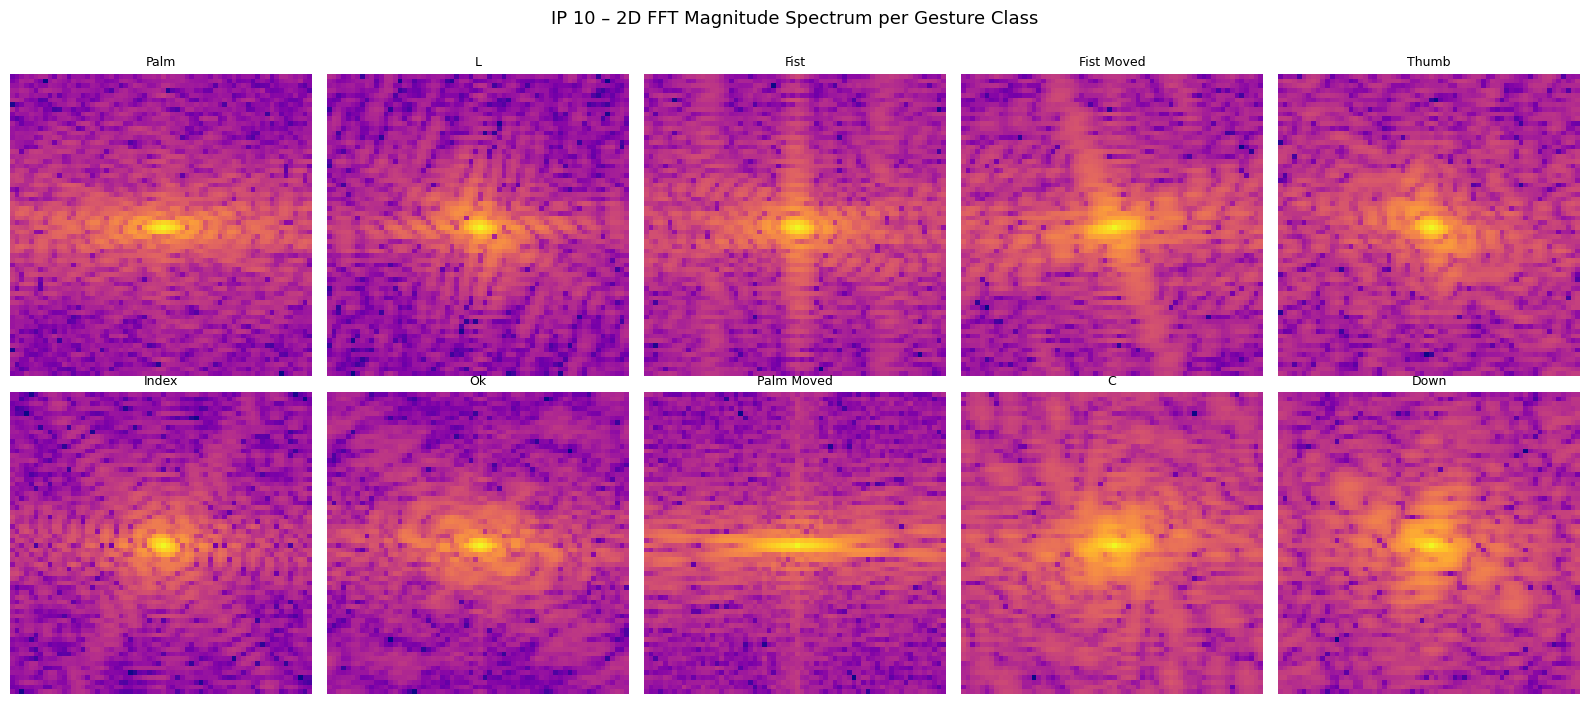

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    f    = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag  = 20 * np.log1p(np.abs(fshift))
    ax.imshow(mag, cmap='plasma'); ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 10 – 2D FFT Magnitude Spectrum per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# Data Preprocessing
<hr>

## Loading and reshaping all images into NumPy arrays


In [ ]:

print("Loading images... (this may take ~1-2 min)")
X_all, y_all = [], []

for _, row in df.iterrows():
    img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_all.append(img)
        y_all.append(row['label'])

X_all = np.array(X_all, dtype='float32')
y_all = np.array(y_all)
print(f"X_all shape: {X_all.shape}  |  y_all shape: {y_all.shape}")


Loading images... (this may take ~1-2 min)
X_all shape: (20000, 64, 64)  |  y_all shape: (20000,)


In [ ]:

from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.10, random_state=42, stratify=y_all)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)  # 0.1111 ≈ 10% of total

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")


Train : (16000, 64, 64)  |  Val : (2000, 64, 64)  |  Test : (2000, 64, 64)


**Reshaping to (N, 64, 64, 1) and normalising pixels to [0, 1]:**

In [ ]:

X_train = X_train.reshape(X_train.shape[0], IMG_SIZE, IMG_SIZE, 1) / 255.0
X_val   = X_val.reshape(X_val.shape[0],     IMG_SIZE, IMG_SIZE, 1) / 255.0
X_test  = X_test.reshape(X_test.shape[0],   IMG_SIZE, IMG_SIZE, 1) / 255.0

y_train = to_categorical(y_train, num_classes=10)
y_val   = to_categorical(y_val,   num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Pixel range → min:", X_train.min(), " max:", X_train.max())


X_train: (16000, 64, 64, 1) y_train: (16000, 10)
X_val  : (2000, 64, 64, 1) y_val  : (2000, 10)
X_test : (2000, 64, 64, 1) y_test : (2000, 10)
Pixel range → min: 0.003921569  max: 0.99215686


## Per-Channel Pixel Mean & Std (Z-Score Normalisation Preview)
Instead of simple /255 normalisation, Z-score standardisation (zero mean, unit std)
is commonly used in gesture recognition. This cell computes and reports the
**dataset-level mean and std** so they can optionally be used for standardisation.


Dataset-level pixel statistics (after /255):
  Mean : 0.09740
  Std  : 0.20745

For Z-score normalisation you would apply:
  X_norm = (X - 0.09740) / 0.20745


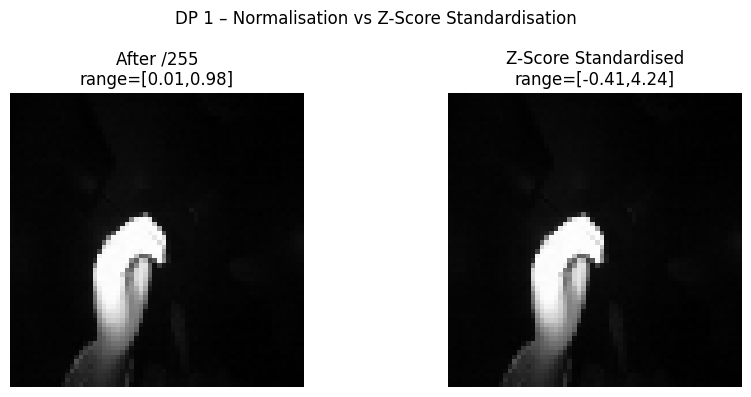

In [ ]:

flat = X_train.ravel()
ds_mean = flat.mean(); ds_std = flat.std()
print(f"Dataset-level pixel statistics (after /255):")
print(f"  Mean : {ds_mean:.5f}")
print(f"  Std  : {ds_std:.5f}")
print(f"\nFor Z-score normalisation you would apply:")
print(f"  X_norm = (X - {ds_mean:.5f}) / {ds_std:.5f}")
# Show before vs after z-score on one image
sample = X_train[0].squeeze()
zscore = (sample - ds_mean) / (ds_std + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample, cmap='gray'); axes[0].set_title(f'After /255\nrange=[{sample.min():.2f},{sample.max():.2f}]')
axes[1].imshow(zscore, cmap='gray'); axes[1].set_title(f'Z-Score Standardised\nrange=[{zscore.min():.2f},{zscore.max():.2f}]')
for ax in axes: ax.axis('off')
plt.suptitle('DP 1 – Normalisation vs Z-Score Standardisation', fontsize=12)
plt.tight_layout(); plt.show()


## Subject-Stratified Split Verification


Split sizes:
  Train: 16000 samples | min class=1600 max class=1600 (balance ratio=1.000)
  Val  :  2000 samples | min class= 200 max class= 200 (balance ratio=1.000)
  Test :  2000 samples | min class= 200 max class= 200 (balance ratio=1.000)


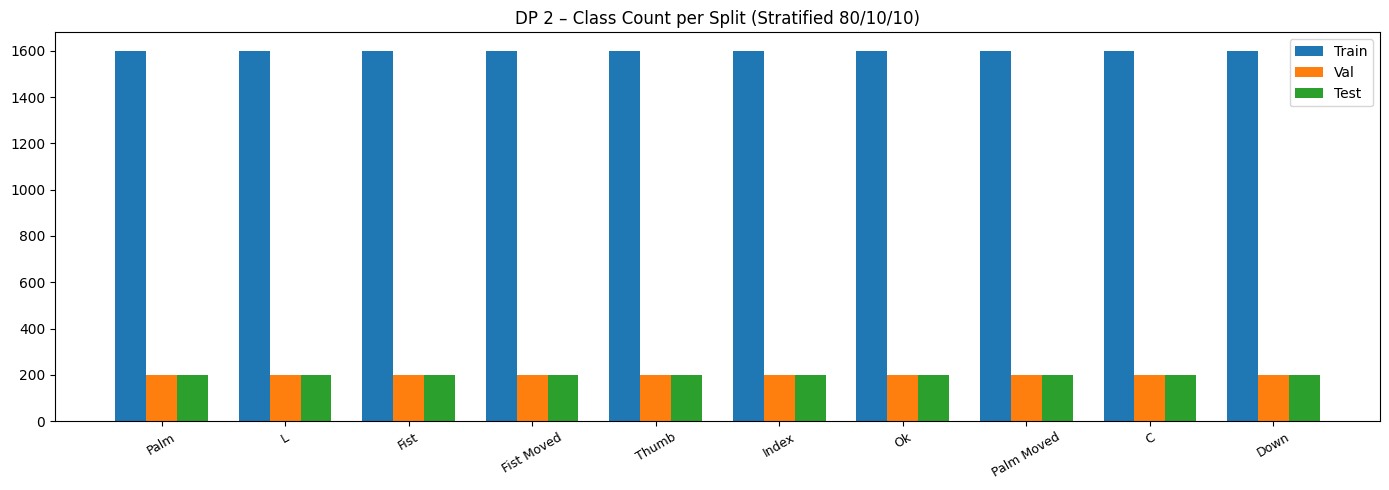

In [ ]:

df_reset   = df.reset_index(drop=True)
y_all_raw  = np.array([r for r in df_reset['label']])  


all_paths = df_reset['filepath'].tolist()


def get_subjects_from_X_paths(X_arr, df_ref):
    # X_arr doesn't store paths; use label counts per gesture to check balance
    y_idx = np.argmax(X_arr if X_arr.ndim == 2 else
                      np.zeros((len(X_arr), 10)), axis=1) if X_arr.ndim==2 else None
    return None

print("Split sizes:")
for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    y_idx   = np.argmax(y, axis=1)
    counts  = {GESTURE_NAMES[g]: (y_idx==g).sum() for g in range(10)}
    total   = len(y_idx)
    cv_vals = list(counts.values())
    print(f"  {name:5s}: {total:5d} samples | "
          f"min class={min(cv_vals):4d} max class={max(cv_vals):4d} "
          f"(balance ratio={min(cv_vals)/max(cv_vals):.3f})")


fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(10); width = 0.25
for idx, (name, y) in enumerate([('Train',y_train),('Val',y_val),('Test',y_test)]):
    y_idx  = np.argmax(y, axis=1)
    counts = [(y_idx==g).sum() for g in range(10)]
    ax.bar(x+idx*width, counts, width, label=name)
ax.set_xticks(x+width)
ax.set_xticklabels([GESTURE_NAMES[g] for g in range(10)], rotation=30, fontsize=9)
ax.set_title('DP 2 – Class Count per Split (Stratified 80/10/10)', fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()


## Data Processing 3 – Foreground Coverage After Normalisation


Foreground fraction (normalised X_train, first 200 images):
  Mean : 0.0801  (8.0% of pixels are hand)
  Std  : 0.0310
  Min  : 0.0273   Max: 0.1777


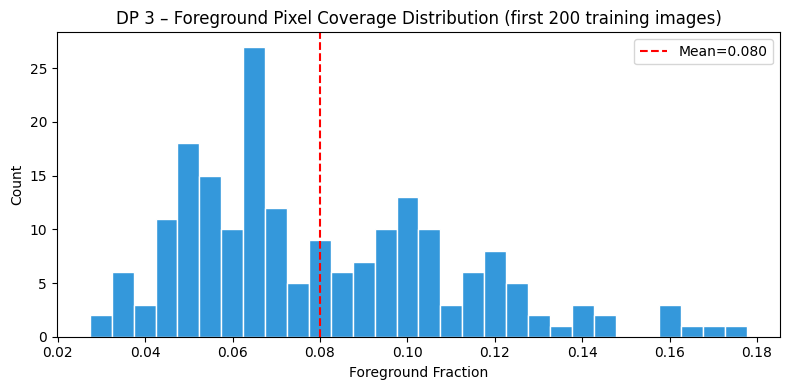

In [ ]:

sample_imgs = X_train[:200].squeeze()     # shape (200, 64, 64), values in [0,1]

fg_fractions = []
for img in sample_imgs:
    img_u8 = (img * 255).astype(np.uint8)
    _, thresh = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fg_fractions.append((thresh > 0).mean())

fg_arr = np.array(fg_fractions)
print(f"Foreground fraction (normalised X_train, first 200 images):")
print(f"  Mean : {fg_arr.mean():.4f}  ({fg_arr.mean()*100:.1f}% of pixels are hand)")
print(f"  Std  : {fg_arr.std():.4f}")
print(f"  Min  : {fg_arr.min():.4f}   Max: {fg_arr.max():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(fg_arr, bins=30, color='#3498db', edgecolor='white')
plt.axvline(fg_arr.mean(), color='red', linestyle='--', label=f'Mean={fg_arr.mean():.3f}')
plt.title('DP 3 – Foreground Pixel Coverage Distribution (first 200 training images)')
plt.xlabel('Foreground Fraction'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()


## HOG Feature Separability (t-SNE on HOG Descriptors)



HOG feature vector length: 1568
Running t-SNE (this takes ~30 sec)…


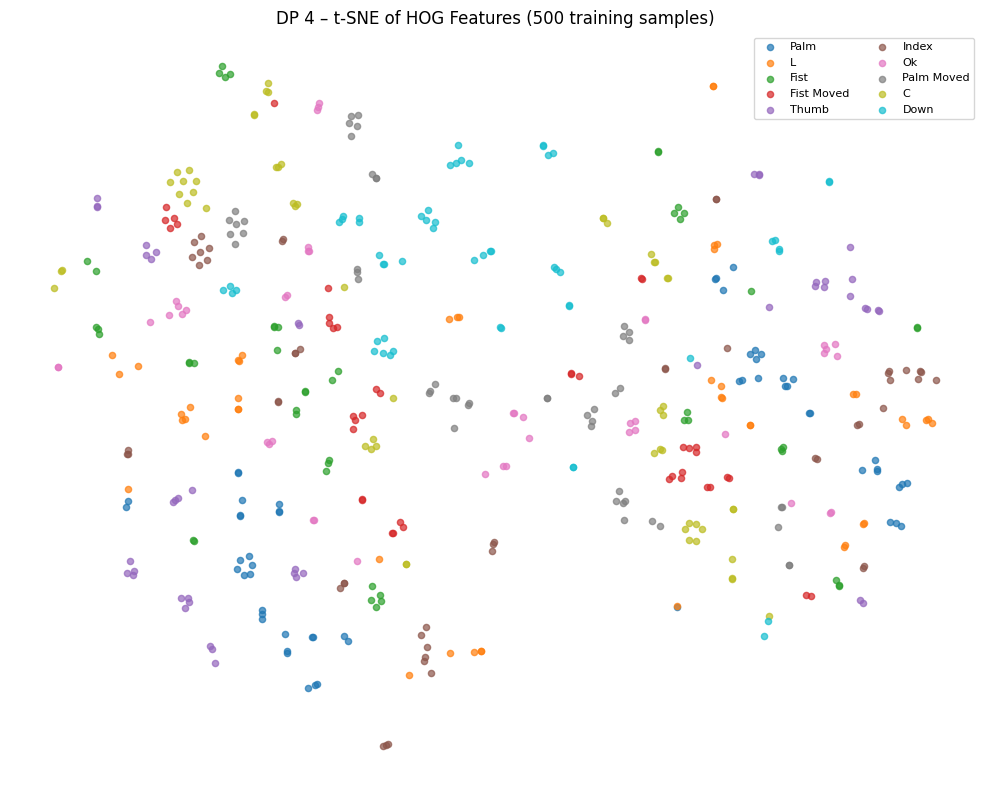

In [ ]:

from skimage.feature import hog
from sklearn.manifold import TSNE

N_SAMPLE  = 500   # one sample per class × N_SAMPLE total
rng       = np.random.RandomState(42)
idx_sample = rng.choice(len(X_train), size=N_SAMPLE, replace=False)

X_sample   = X_train[idx_sample].squeeze()   # (500, 64, 64)
y_sample   = np.argmax(y_train[idx_sample], axis=1)

hog_feats = []
for img in X_sample:
    img_u8 = (img * 255).astype(np.uint8)
    fd = hog(img_u8, orientations=8, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    hog_feats.append(fd)
hog_feats = np.array(hog_feats)

print(f"HOG feature vector length: {hog_feats.shape[1]}")
print("Running t-SNE (this takes ~30 sec)…")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=800)
emb  = tsne.fit_transform(hog_feats)

colors10 = plt.cm.tab10(np.linspace(0,1,10))
fig, ax  = plt.subplots(figsize=(10, 8))
for gid in range(10):
    mask = y_sample == gid
    ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.7,
               color=colors10[gid], label=GESTURE_NAMES[gid])
ax.set_title('DP 4 – t-SNE of HOG Features (500 training samples)', fontsize=12)
ax.legend(fontsize=8, ncol=2); ax.axis('off')
plt.tight_layout(); plt.show()


##  Pixel Variance Map per Gesture Class



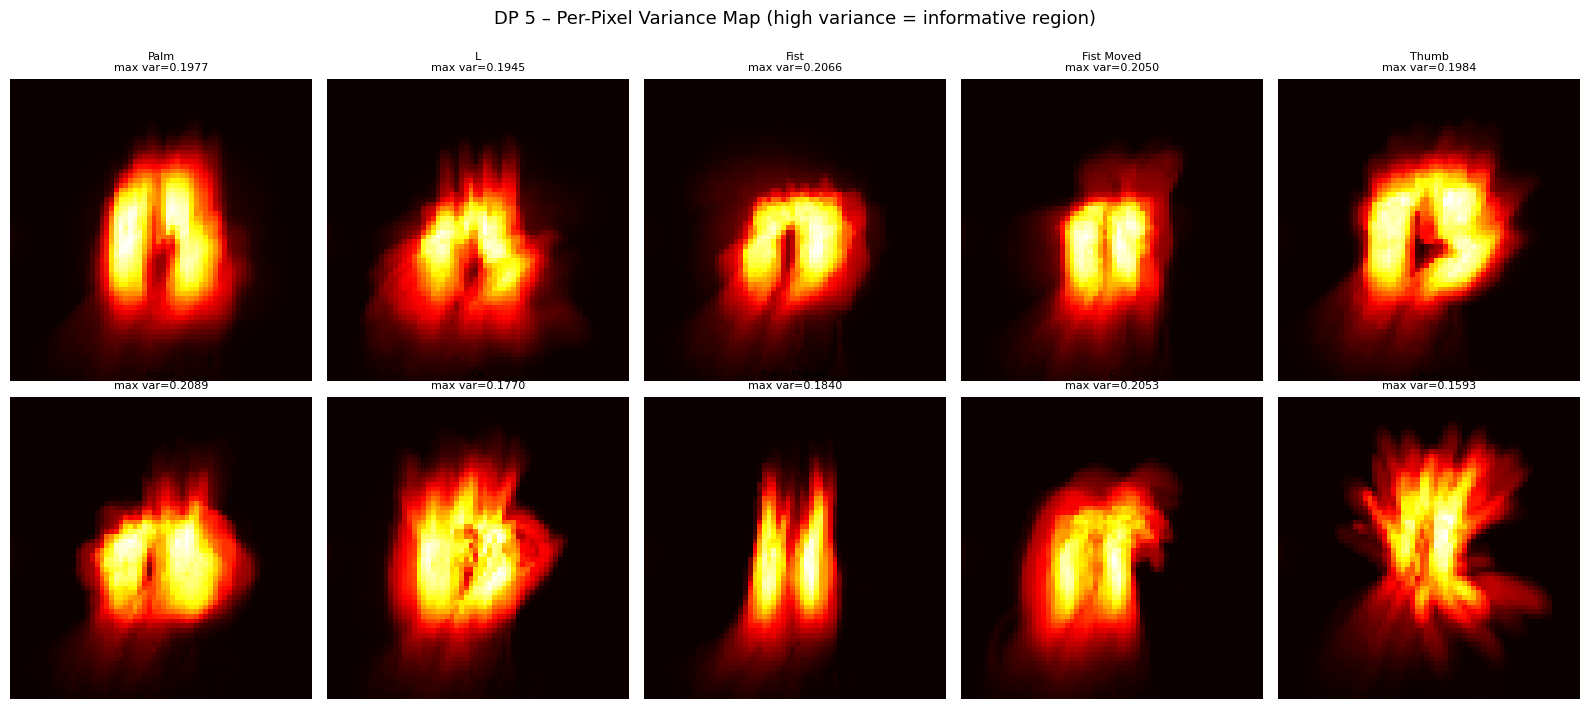

In [ ]:


fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    class_imgs = X_train[y_train_idx == gid].squeeze()  # (N, 64, 64)
    var_map    = class_imgs.var(axis=0)
    im = ax.imshow(var_map, cmap='hot')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nmax var={var_map.max():.4f}', fontsize=8)
    ax.axis('off')

plt.suptitle('DP 5 – Per-Pixel Variance Map (high variance = informative region)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
